# Week Problem Set: Data Wrangling

## Context
You are a Data Scientist at a regional health center. Patient data is divided across three systems:
- Administrative
- Lab Results
- Lifestyle Surveys

For this assignment, you will work with these datasets **independently** and focus only on **data wrangling tasks**.

---

## Datasets
1. patient_demographics.csv  
   - Patient ID, Age, Sex, Geography
     

2. clinical_data.csv  
   - Patient ID, Cholesterol, Blood Pressure ("120/80"), BMI
  

3. lifestyle_factors.csv  
   - Patient ID, Smoking, Diet, Heart Attack Risk (Target)

---

## Objectives
- Inspecting structure and quality
- Handling missing values
- Fixing data formats
- Identifying and treating anomalies

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically
- Make decisions (and justify them)
- Explore different approaches

---

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Download the following CSV files from Google Classroom to your computer:

- patient_demographics.csv
- clinical_data.csv
- lifestyle_factors.csv

Run the code below and upload the files.

In [2]:
# from google.colab import files
# uploaded = files.upload()

In [3]:
# Load datasets
demographics = pd.read_csv("./patient_demographics.csv")
clinical = pd.read_csv("./clinical_data.csv")
lifestyle = pd.read_csv("./lifestyle_factors.csv")

# Basic Inspection

## Tasks:
- View first few rows
- Check datatypes
- Look at summary statistics

## Questions:
- Are there obvious data issues?
- Are datatypes appropriate?

## Hint:
- Use `.head()`, `.info()`, `.describe()` for all three dataframes to get a full picture of the data quality.
- Pandas documentation for reference: https://pandas.pydata.org/docs/user_guide/10min.html

In [4]:
# Your code here
demographics.head()

,Patient ID,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,66,Male,160555,Thailand,Asia,Northern Hemisphere


In [5]:
# Your code here
demographics.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Patient ID  8763 non-null   str  
 1   Age         8763 non-null   int64
 2   Sex         8763 non-null   str  
 3   Income      8763 non-null   int64
 4   Country     8763 non-null   str  
 5   Continent   8763 non-null   str  
 6   Hemisphere  8763 non-null   str  
dtypes: int64(2), str(5)
memory usage: 479.4 KB


In [6]:
# Your code here
demographics.describe()

,Age,Income
count,8763.000000,8763.000000
mean,53.707977,158263.181901
std,21.249509,80575.190806
min,18.000000,20062.000000
25%,35.000000,88310.000000
50%,54.000000,157866.000000
75%,72.000000,227749.000000
max,90.000000,299954.000000


In [7]:
clinical.head()

,Patient ID,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Triglycerides,BMI
0,BMW7812,208,158/88,72,0,0,286,31.251233
1,CZE1114,389,165/93,98,1,1,235,27.194973
2,BNI9906,324,174/99,72,1,0,587,28.176571
3,JLN3497,383,163/100,73,1,1,378,36.464704
4,GFO8847,318,91/88,93,1,1,231,21.809144


In [8]:
clinical.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Patient ID      8763 non-null   str    
 1   Cholesterol     8763 non-null   int64  
 2   Blood Pressure  8763 non-null   str    
 3   Heart Rate      8763 non-null   int64  
 4   Diabetes        8763 non-null   int64  
 5   Family History  8763 non-null   int64  
 6   Triglycerides   8763 non-null   int64  
 7   BMI             8763 non-null   float64
dtypes: float64(1), int64(5), str(2)
memory usage: 547.8 KB


In [9]:
clinical.describe()

,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,259.877211,75.021682,0.652288,0.492982,417.677051,28.891446
std,80.863276,20.550948,0.476271,0.499979,223.748137,6.319181
min,120.000000,40.000000,0.000000,0.000000,30.000000,18.002337
25%,192.000000,57.000000,0.000000,0.000000,225.500000,23.422985
50%,259.000000,75.000000,1.000000,0.000000,417.000000,28.768999
75%,330.000000,93.000000,1.000000,1.000000,612.000000,34.324594
max,400.000000,110.000000,1.000000,1.000000,800.000000,39.997211


In [10]:
lifestyle.head()

,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk
0,BMW7812,1,0,0,4.168189,Average,9,0
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0
2,BNI9906,0,0,0,2.078353,Healthy,9,0
3,JLN3497,1,0,1,9.828130,Average,9,0
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0


In [11]:
lifestyle.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               8763 non-null   str    
 1   Smoking                  8763 non-null   int64  
 2   Obesity                  8763 non-null   int64  
 3   Alcohol Consumption      8763 non-null   int64  
 4   Exercise Hours Per Week  8763 non-null   float64
 5   Diet                     8763 non-null   str    
 6   Stress Level             8763 non-null   int64  
 7   Heart Attack Risk        8763 non-null   int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 547.8 KB


In [12]:
lifestyle.describe()

,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Stress Level,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,0.896839,0.501426,0.598083,10.014284,5.469702,0.358211
std,0.304186,0.500026,0.490313,5.783745,2.859622,0.479502
min,0.000000,0.000000,0.000000,0.002442,1.000000,0.000000
25%,1.000000,0.000000,0.000000,4.981579,3.000000,0.000000
50%,1.000000,1.000000,1.000000,10.069559,5.000000,0.000000
75%,1.000000,1.000000,1.000000,15.050018,8.000000,1.000000
max,1.000000,1.000000,1.000000,19.998709,10.000000,1.000000


# Data Cleaning

## 1. Blood Pressure Column

### Task:
- Inspect the Blood Pressure column

### Questions:
- Is it stored as a number or string?
- Can we compute averages directly?

### Hint:
- Format looks like "120/80"
- Consider splitting into two columns
- https://pandas.pydata.org/docs/reference/api/pandas.Series.str.split.html

### Consequences:
- Keeping as string -> limits analysis
- Splitting -> enables calculations but increases feature count

In [13]:
copied_clinical = clinical.copy()
copied_clinical['Blood Pressure'].dtype

<StringDtype(storage='python', na_value=nan)>

In [14]:

# Your code here
copied_clinical[['systolic', 'diastolic']] = copied_clinical['Blood Pressure'].str.split(pat="/", expand=True).astype(int)


In [15]:
copied_clinical[['systolic', 'diastolic']].dtypes

systolic     int64
diastolic    int64
dtype: object

In [16]:
copied_clinical.drop(columns=['Blood Pressure'], inplace=True)

In [17]:
copied_clinical.head()

,Patient ID,Cholesterol,Heart Rate,Diabetes,Family History,Triglycerides,BMI,systolic,diastolic
0,BMW7812,208,72,0,0,286,31.251233,158,88
1,CZE1114,389,98,1,1,235,27.194973,165,93
2,BNI9906,324,72,1,0,587,28.176571,174,99
3,JLN3497,383,73,1,1,378,36.464704,163,100
4,GFO8847,318,93,1,1,231,21.809144,91,88


## 2. Missing Values

### Task:
Identify columns with null values

### Questions:
- Which columns have missing values?
- Why might values be missing?

### Hint:
- Lifestyle → user did not answer (non-critical)
- Clinical → test not performed (critical)
- https://wesmckinney.com/book/data-cleaning

### Why Missing Data Matters
Missing data is not just an inconvenience, it can affect the **validity of your analysis**.

There are different types of missingness:
- **MCAR (Missing Completely at Random)** → no pattern (least problematic)
- **MAR (Missing at Random)** → depends on other variables
- **MNAR (Missing Not at Random)** → depends on the missing value itself (most problematic)

Understanding *why* data is missing helps decide how to handle it.

### Consequences of Different Choices

#### 1. Dropping Missing Values (`dropna`)
- Pros: simple, clean dataset  
- Cons: loses data, may introduce bias  

---

#### 2. Filling Missing Values (`fillna`)
- Pros: keeps dataset size, usable for modeling  
- Cons: adds assumptions, can distort data  

---

#### 3. Column-Specific Strategy
- Clinical → careful imputation or flag missing  
- Lifestyle → consider "Unknown" category  

### Key Takeaway:
There is **no single correct method**.  
The best approach depends on:
- Why data is missing  
- How much is missing  
- The impact on downstream analysis  


In [18]:
# Your code here
lifestyle.isna().sum()

Patient ID                 0
Smoking                    0
Obesity                    0
Alcohol Consumption        0
Exercise Hours Per Week    0
Diet                       0
Stress Level               0
Heart Attack Risk          0
dtype: int64

In [19]:
# Your code here
copied_clinical.isna().sum()

Patient ID        0
Cholesterol       0
Heart Rate        0
Diabetes          0
Family History    0
Triglycerides     0
BMI               0
systolic          0
diastolic         0
dtype: int64

In [20]:
# Your code here
demographics.isna().sum()

Patient ID    0
Age           0
Sex           0
Income        0
Country       0
Continent     0
Hemisphere    0
dtype: int64

# Exploratory Data Analysis (EDA)

## Univariate Analysis: Age Distribution

Univariate analysis examines **one variable at a time**.
The goal is to understand each column's distribution, central tendency, and spread before comparing variables.

We split variables into two types:
- **Numerical** (continuous): Age, Cholesterol, BMI, Blood Pressure
- **Categorical** (discrete): Sex, Smoking, Diet, Country

---

## 1. Numerical Variables : Distributions

### Task:
Plot histograms and KDE (Kernel Density Estimate) curves for: Age, Cholesterol, BMI

### Questions:
- Which variables are normally distributed?
- Which variables are skewed left or right?
- Are there any unexpected spikes or gaps?
- Based on the distribution shape, would any feature likely need a transformation before modeling?

### Hint:
- `sns.histplot(data=df, x='Age', kde=True)` draws a histogram with a density curve
- `plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')` adds a mean line
- Skewness > 1 or < -1 is considered highly skewed

## Why This Matters

Many statistical models, such as **Linear Regression, Logistic Regression, and Linear Discriminant Analysis** assume that numerical features are approximately **normally distributed**. When this assumption is violated, it can lead to:

- Biased coefficients  
- Unreliable p-values  
- Poor model performance  

Even though tree-based models (like Decision Trees) do not require normality, highly skewed features can still negatively affect **distance-based algorithms** such as **KNN** or **SVM**.

This is why understanding the shape of your distributions early in **Exploratory Data Analysis (EDA)** is important. It helps determine whether transformations are needed before modeling.

---

## Common Transformations and When to Use Them

### 1. Log Transform — `np.log1p(x)`
Used when data is **right-skewed** (long tail on the right), such as income or cholesterol levels in some populations.

- Compresses large values  
- Pulls distribution closer to normal  
- Uses `log1p` (log(1 + x)) to safely handle zero values  

---

### 2. Square Root Transform — `np.sqrt(x)`
A milder transformation compared to log.

- Useful for **moderately right-skewed data**  
- Common for count data (e.g., number of medications)  
- Preserves more of the original structure  

---

### 3. Box-Cox Transform — `scipy.stats.boxcox(x)`
A powerful, data-driven transformation.

- Finds optimal power (λ) to best approximate normality  
- Requires all values to be **strictly positive**  
- Special cases:
  - λ = 0 → log transform  
  - λ = 0.5 → square root transform  

---

### 4. Yeo-Johnson Transform — `sklearn.preprocessing.PowerTransformer(method='yeo-johnson')`
A flexible alternative to Box-Cox.

- Works with **zero and negative values**  
- More suitable for real-world medical datasets  
- Automatically learns best transformation  

---

### 5. Standardization (Z-score) — `sklearn.preprocessing.StandardScaler`
Transforms features to have:

- Mean = 0  
- Standard deviation = 1  

Notes:

- Does **not change distribution shape**  
- Useful when features are on different scales (e.g., Age vs Cholesterol)  
- Does not fix skewness  

---

### 6. Min-Max Normalization — `sklearn.preprocessing.MinMaxScaler`
Rescales features to a fixed range:

- Values are scaled to **[0, 1]**  
- Does not fix skewness  

---

### Reference links:
- https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45/
- https://www.geeksforgeeks.org/python/data-normalization-with-pandas/


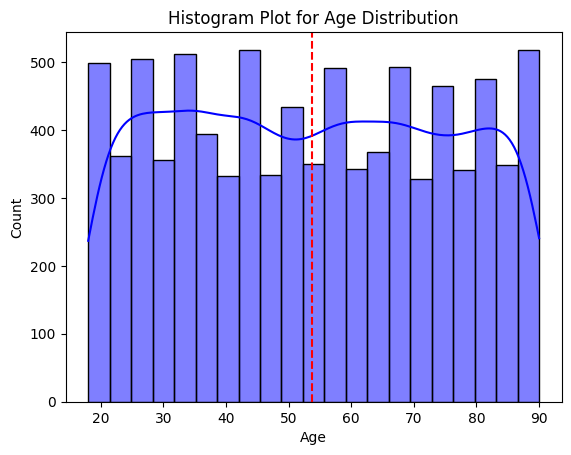

Age Skewness = 0.028497567159389184


In [21]:
# Your code here
sns.histplot(data=demographics, x="Age", kde=True, color='b')
plt.axvline(demographics['Age'].mean(),linestyle='--', color='r', label='Mean Age')
plt.title("Histogram Plot for Age Distribution")
plt.show()

print(f"Age Skewness = {demographics['Age'].skew()}")

<strong><li>The distribution is approximate to Normal distrubution.</li><li>Also,the distribution is platykurtic.</li><li>The data is slightly positively skewed</li><li>No sudden peaks observed in the data.</li><li>Transformation is not required</li></strong>

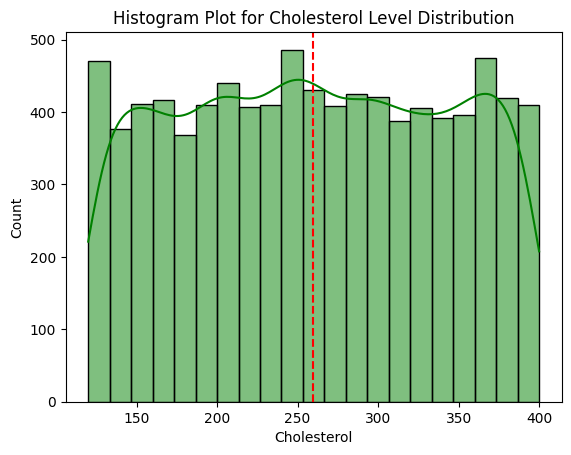

Age Skewness = -0.0009547396917188217


In [22]:
# Your code here
sns.histplot(data=clinical, x="Cholesterol", kde=True, color='g')
plt.axvline(clinical['Cholesterol'].mean(),linestyle='--', color='r', label='Mean Cholesterol')
plt.title("Histogram Plot for Cholesterol Level Distribution")
plt.show()

print(f"Age Skewness = {clinical['Cholesterol'].skew()}")

<strong><li>The distribution is approximate to Normal distrubution.</li><li>Also,the distribution is platykurtic.</li><li>The data are almost perfectly skewed</li><li>Slightly peaks are observed in the data.</li><li>We can use Standardization (z-score) in this case.</li></strong>

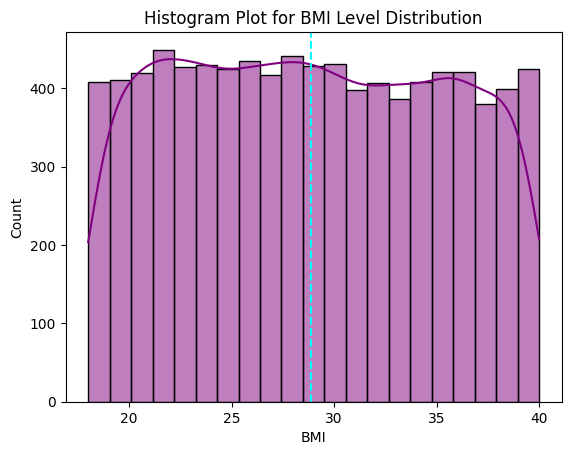

Age Skewness = 0.035996421727899


In [23]:
# Your code here
sns.histplot(data=clinical, x="BMI", kde=True, color='purple')
plt.axvline(clinical['BMI'].mean(),linestyle='--', color='cyan', label='Mean BMI')
plt.title("Histogram Plot for BMI Level Distribution")
plt.show()

print(f"Age Skewness = {clinical['BMI'].skew()}")

<strong><li>The distribution is approximate to Normal distrubution.</li><li>Also,the distribution is platykurtic.</li><li>The data is slightly positively skewed</li><li>Sudden peaks are observed in the data.</li><li>Using Yeo-Johnson transformation may help in achieving the normality in the distribution.</li></strong>

## 2. Categorical Variables : Bar Charts

### Task:
Plot bar charts showing the frequency distribution of: Smoking Status, Diet Quality, and Top 10 Countries

### Questions:
- What proportion of patients smoke?
- Which diet category is most common?
- Which countries are most represented?

### Hint:
- `sns.countplot(data=df, x='Smoking', order=df['Smoking'].value_counts().index)` orders bars by frequency
- For Country, filter to top 10: `df['Country'].value_counts().head(10)`
- Rotate x-axis labels if needed: `plt.xticks(rotation=45)`

### Why This Matters:
Imbalanced categories (e.g., 90% male patients) can introduce bias into analyses. Knowing category proportions helps interpret group-level results accurately.

Proportion of smokers: 0.90


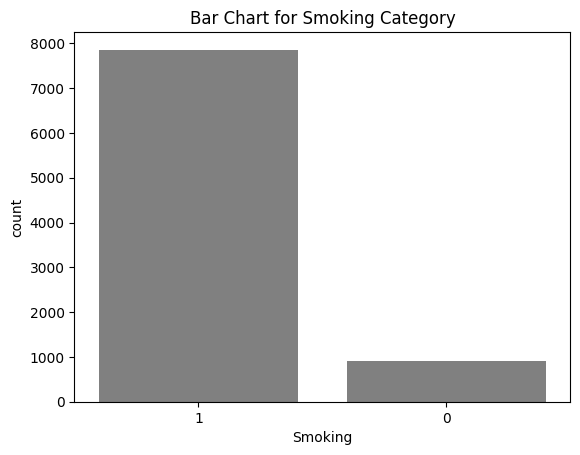

In [24]:
sns.countplot(data=lifestyle, x=lifestyle['Smoking'], order=lifestyle['Smoking'].value_counts().index, color='grey')
plt.title("Bar Chart for Smoking Category")

# Proportion of patient who smoke
smokers = lifestyle['Smoking'].value_counts()[1]
total_population = lifestyle['Smoking'].value_counts().sum()
smokers_proportion = smokers / total_population
print(f"Proportion of smokers: {smokers_proportion:.2f}")

Diet
Healthy      2960
Average      2912
Unhealthy    2891
Name: count, dtype: int64

'Healthy Diet Category is most common'


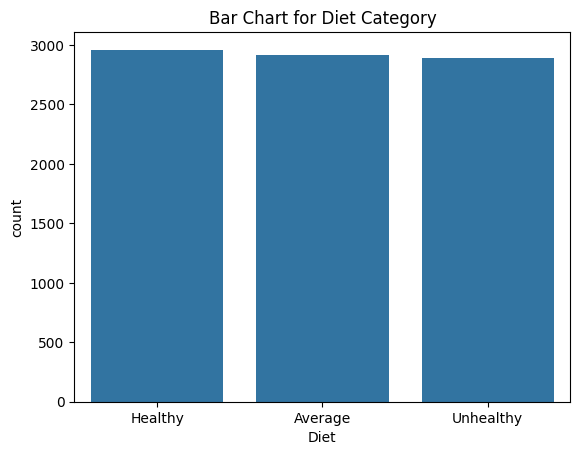

In [25]:
# Most common diet category
sns.countplot(data= lifestyle, x= 'Diet', order= lifestyle['Diet'].value_counts().index)
plt.title("Bar Chart for Diet Category")

#Common diet category
print(lifestyle['Diet'].value_counts())
print()
print("'Healthy Diet Category is most common'")

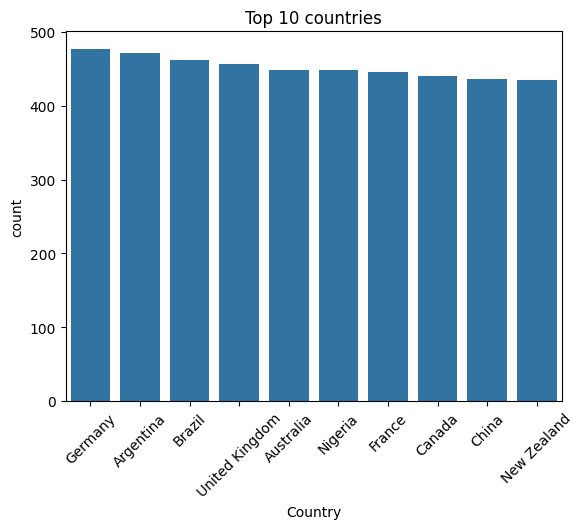

Index(['Germany', 'Argentina', 'Brazil', 'United Kingdom', 'Australia',
       'Nigeria', 'France', 'Canada', 'China', 'New Zealand'],
      dtype='str', name='Country')


In [26]:
top10 = demographics['Country'].value_counts().head(10).index
sns.countplot(data=demographics[demographics['Country'].isin(top10)], x = "Country", order=top10)
plt.xticks(rotation= 45)
plt.title("Top 10 countries")
plt.show()

# Most represented countries
print(top10)

# Bivariate Analysis : Features vs Target

## Context
Bivariate analysis explores the relationship **between two variables**.
Here, we are specifically interested in how each feature relates to `Heart Attack Risk` (our target).

This is where we start forming hypotheses:
- Do smokers have higher risk?
- Does diet quality affect risk?
- Does cholesterol level differ between risk groups?

---

## Categorical Features vs Heart Attack Risk (Grouped Bar Charts)

### Task:
For the categorical features: Smoking, Diet, Sex, create a grouped bar chart showing the count of At-Risk vs Not-At-Risk patients within each category.

### Questions:
- Do smokers show noticeably higher risk counts?
- Does diet quality appear protective against heart attack risk?
- Is there a difference in risk between male and female patients?

### Hint:
- `sns.countplot(data=df, x='Smoking', hue='Heart Attack Risk')` creates grouped bars automatically
- `hue` splits each bar group by the target variable
- To see proportions (not raw counts) within groups, compute:
  `df.groupby('Smoking')['Heart Attack Risk'].mean()` → gives risk rate per group

### Why This Matters:
Raw counts can be misleading if groups have unequal sizes. Consider also plotting proportions (risk rate) to compare groups fairly.

In [27]:
smoking_heart_attack_risk_proportions = lifestyle.groupby('Smoking')['Heart Attack Risk'].mean()
print(smoking_heart_attack_risk_proportions)

Smoking
0    0.363938
1    0.357552
Name: Heart Attack Risk, dtype: float64


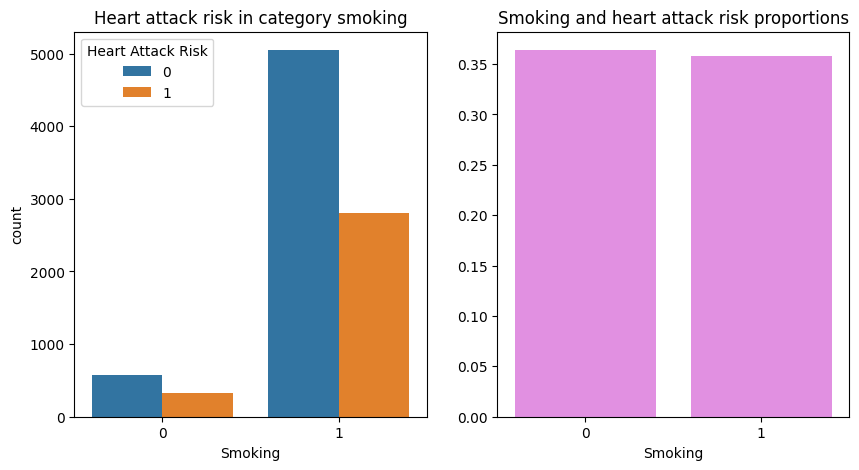

In [28]:
# Your code here
plt.figure(figsize= (10,5))
plt.subplot(1,2,1)
sns.countplot(data= lifestyle, x = "Smoking", hue="Heart Attack Risk")
plt.title("Heart attack risk in category smoking")
plt.subplot(1,2,2)
sns.barplot(x= smoking_heart_attack_risk_proportions.index, 
            y= smoking_heart_attack_risk_proportions.values,
            color='violet')
plt.title("Smoking and heart attack risk proportions")
plt.show()



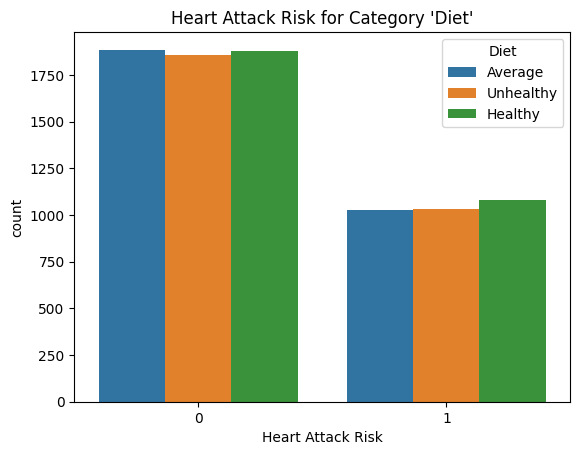

In [29]:
sns.countplot(data= lifestyle, x='Heart Attack Risk', hue='Diet')
plt.title("Heart Attack Risk for Category 'Diet'")
plt.show()


In [30]:
joined_demo_life = pd.merge(lifestyle, demographics, on='Patient ID', how='inner')
joined_demo_life.head()


,Patient ID,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Stress Level,Heart Attack Risk,Age,Sex,Income,Country,Continent,Hemisphere
0,BMW7812,1,0,0,4.168189,Average,9,0,67,Male,261404,Argentina,South America,Southern Hemisphere
1,CZE1114,1,1,1,1.813242,Unhealthy,1,0,21,Male,285768,Canada,North America,Northern Hemisphere
2,BNI9906,0,0,0,2.078353,Healthy,9,0,21,Female,235282,France,Europe,Northern Hemisphere
3,JLN3497,1,0,1,9.828130,Average,9,0,84,Male,125640,Canada,North America,Northern Hemisphere
4,GFO8847,1,1,0,5.804299,Unhealthy,6,0,66,Male,160555,Thailand,Asia,Northern Hemisphere


In [31]:
gender_heart_attack_risk_proportions = joined_demo_life.groupby('Sex')['Heart Attack Risk'].mean()

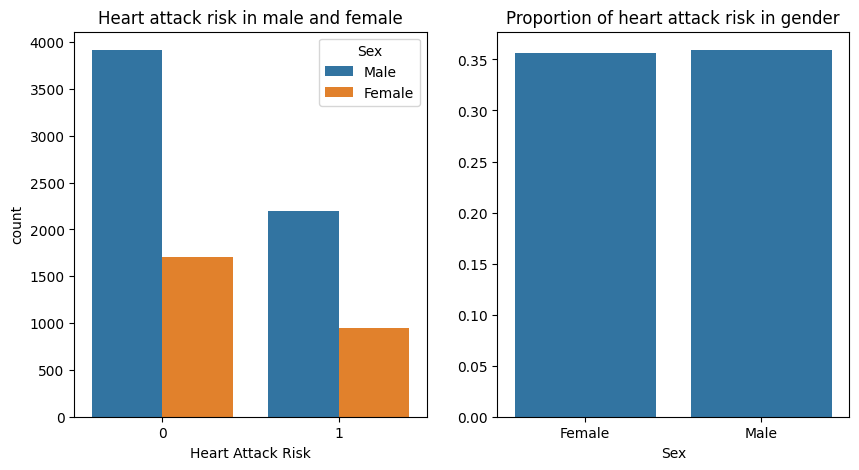

In [32]:
# Your code here
plt.figure(figsize= (10,5))
plt.subplot(1,2,1)
sns.countplot(data=joined_demo_life, x='Heart Attack Risk', hue='Sex')
plt.title("Heart attack risk in male and female")

plt.subplot(1,2,2)
sns.barplot(x= gender_heart_attack_risk_proportions.index, 
            y= gender_heart_attack_risk_proportions.values,
            )
plt.title("Proportion of heart attack risk in gender")
plt.show()

# Correlation Analysis

## Context
Correlation measures **how strongly two numerical variables move together**.

### Some types of Correlation Coefficient:
| Coefficient | Use Case | Range |
|---|---|---|
| **Pearson** | Linear relationship between continuous variables | -1 to +1 |
| **Spearman** | Monotonic (ranked) relationship; robust to outliers | -1 to +1 |

### Interpretation Guide:
- |r| > 0.7 → Strong correlation  
- |r| 0.4–0.7 → Moderate correlation  
- |r| < 0.4 → Weak correlation  
- Sign (+ or -) tells direction: positive = both increase together, negative = one increases as other decreases

---

## Pearson Correlation Heatmap

### Task:
Calculate and visualize the Pearson correlation matrix for all numerical columns including the target.

### Questions:
- Which feature has the highest correlation with Heart Attack Risk?
- Are any features highly correlated with each other (multicollinearity)?
- Does Systolic BP correlate strongly with Diastolic BP? Why might that be expected?

### Hint:
- `df[numeric_cols].corr(method='pearson')` computes the correlation matrix
- `sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')` visualizes it
- `mask = np.triu(np.ones_like(corr_matrix))` removes the duplicate upper triangle

### Warning:
Pearson assumes linearity and is sensitive to outliers. For skewed distributions, consider Spearman instead.

In [33]:
combined_df = pd.merge(copied_clinical, lifestyle, how='inner').merge(demographics, how='inner')
numeric = combined_df.select_dtypes(include='number')
categoric = combined_df.select_dtypes(include='str')

<Axes: >

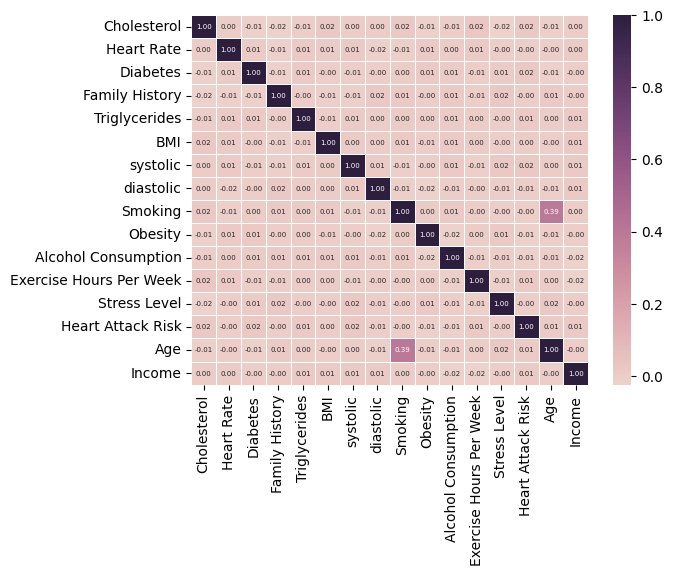

In [34]:
numeric_corr = numeric.corr(method='pearson')
sns.heatmap(numeric_corr, annot=True, fmt='.2f', linewidths=.5, cmap=sns.cubehelix_palette(as_cmap=True), annot_kws={"size": 5})

In [35]:
categoric[['Diet','Sex','Country','Continent','Hemisphere',]].describe()

,Diet,Sex,Country,Continent,Hemisphere
count,8763,8763,8763,8763,8763
unique,3,2,20,6,2
top,Healthy,Male,Germany,Asia,Northern Hemisphere
freq,2960,6111,477,2543,5660


In [36]:
pd.get_dummies(data=categoric, columns=['Sex', 'Hemisphere', 'Diet', 'Country', 'Continent'], dtype=int, drop_first=True)
categoric.drop(columns=['Patient ID'], inplace=True)

In [37]:
categoric['Heart Attack Risk'] = lifestyle['Heart Attack Risk']
plt.figure(figsize=(12,10))
sns.heatmap(categoric.corr(method='pearson'), annot=True, annot_kws={"size": 5}, cmap='crest')

ValueError: could not convert string to float: 'Average'

<Figure size 1200x1000 with 0 Axes>

Correlation (Pearsons) between systolic and diastolic BP:  0.013337009298239387


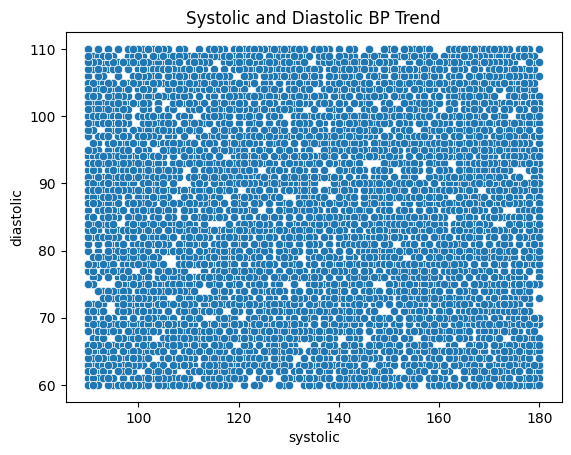

In [ ]:
# Your code here
sys_dias_pear_corr = copied_clinical['systolic'].corr(copied_clinical['diastolic'], method='pearson')
print("Correlation (Pearsons) between systolic and diastolic BP: ", sys_dias_pear_corr)
sns.scatterplot(data=copied_clinical, x='systolic', y='diastolic')
plt.title("Systolic and Diastolic BP Trend")
plt.show()

# Spearman Correlation

### Task:
Repeat the correlation analysis using Spearman's rank correlation.

### Questions:
- Are the Spearman results significantly different from Pearson?
- If they differ, what might that suggest about the data's linearity or outliers?

### Hint:
- Use `method='spearman'` in `.corr()`
- Compare the two heatmaps side by side using `plt.subplots(1, 2)`

### Interpretation:
Large differences between Pearson and Spearman suggest the relationship is non-linear or that outliers are influencing Pearson.

<Axes: >

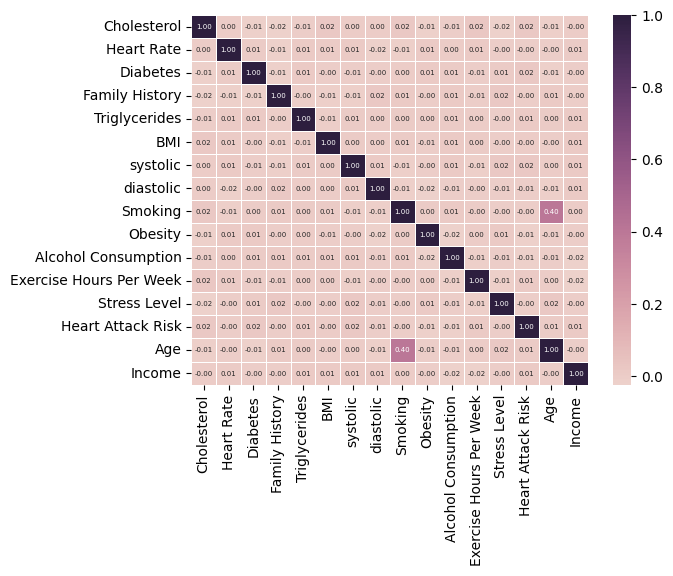

In [ ]:
# Your code here
sns.heatmap(numeric.corr(method='spearman'), annot=True, fmt='.2f', linewidths=.5, cmap=sns.cubehelix_palette(as_cmap=True), annot_kws={"size": 5})

<Axes: >

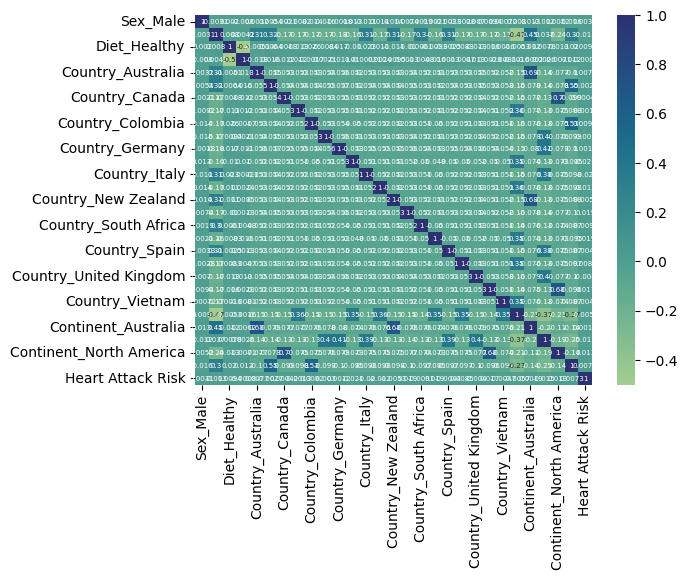

In [ ]:
# Your code here
sns.heatmap(categoric.corr(method='spearman'), annot=True, annot_kws={"size": 5}, cmap='crest')

## Target Variable Analysis: Heart Attack Risk

## Context
Target variable is the variable that the user would want to predict using the rest of the dataset.

`Heart Attack Risk` is a **binary variable**: 0 (No Risk) and 1 (At Risk).

## Tasks:
- Count how many patients fall into each class
- Visualize the class distribution with a bar chart

## Hint:
- Use `.value_counts()` to get counts
- Use `sns.countplot()` or `plt.bar()` for visualization


In [ ]:
# Your code here
lifestyle['Heart Attack Risk'].value_counts()

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

Text(0.5, 1.0, 'Heart Attack Risk Patients')

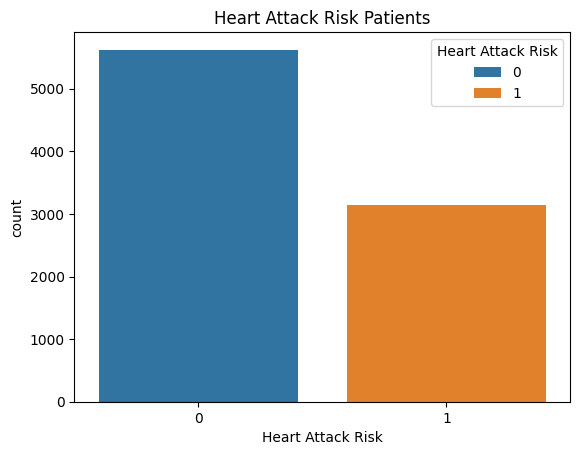

In [ ]:
# Your code here
sns.countplot(data=lifestyle,
              x='Heart Attack Risk',
              hue='Heart Attack Risk')
plt.title("Heart Attack Risk Patients")

# Final Reflection

## Answer the following:

### 1. Missing Values
- How did you handle missing values in each dataset?
- Why did you choose that approach (drop, fill, or mixed strategy)?

---

### 2. Data Quality Issues
- Did you find any unrealistic or inconsistent values?
- How did you identify them?
- What action did you take (remove, clip, correct, or keep)?

---

### 3. Insights from EDA
- What patterns did you observe in the data?
- Did you find any relationships between variables (e.g., age, cholesterol, risk)?
- Were there any surprising findings or trends?

---

### 4. Correlation Findings
- Were Pearson and Spearman results similar or different? What does that suggest?
- Did you find any multicollinearity (two features highly correlated with each other)?

---

### 5. Improvements
- If you had more time, what would you improve in your data cleaning process?
- Would you try different strategies for missing values or outliers?
- What additional checks or visualizations would you add?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying your decisions  
- Explaining trade-offs  
- Demonstrating understanding of data quality impact  

### Answer here:

<strong>Note: Formatting and some corrections for the answers were made using AI</strong>


## Question 1: Missing Value Detection

- Missing values were detected using `df.isna().sum()`.
- No missing values were found in the given dataset.

---

## Question 2: Data Type Correction

- The blood pressure column was identified as string (`str`) type, which is unsuitable for numerical processing.
- The values were cleaned using `df.str.strip()` to remove whitespace and subsequently converted to integer (`int`) data type.

---

## Question 3: Exploratory Data Analysis (EDA)

- Most variables were observed to follow an approximate normal distribution with a platykurtic nature.
- A positive correlation was identified between age and smoking.
- The relationship between heart attack risk and both smoking and diet yielded unexpected results. Despite initial expectations that these would be significant contributing factors, only a very weak positive correlation was found.

---

## Question 4: Correlation Analysis

- Pearson and Spearman correlation methods produced nearly identical results for the given dataset.
- Age and smoking were found to be correlated with each other.

---

## Question 5: Improvements and Future Work

- Given more time, alternative approaches to handling categorical variables would be explored. One-hot encoding was used in this assignment, which increases the dimensionality of the dataset. It would be valuable to investigate how high-cardinality categorical features are handled in real-world processing pipelines.
- Additional visualizations would also be explored, including box plots for outlier detection and density plots to observe the distribution of one variable across multiple categories.

